<a href="https://colab.research.google.com/github/koewilliams5/DI-Bootcamp/blob/main/BuildingTrustworthy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
import json
from transformers import DistilBertForSequenceClassification

# Optimisation : On initialise le modèle d'explication une seule fois à l'extérieur
print("Initialisation du module d'explicabilité (eager mode)...")
model_explain = DistilBertForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=3,
    attn_implementation="eager"
).to(model.device)
model_explain.load_state_dict(model.state_dict())
model_explain.eval()

def analyze_text(text):
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model_explain(**inputs, output_attentions=True)
        attentions = outputs.attentions

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    conf, pred_idx = torch.max(probs, dim=-1)
    label = label_names[pred_idx.item()]

    evidence = []
    if attentions is not None:
        # Extraction de la dernière couche d'attention
        last_layer = attentions[-1][0].mean(dim=0)
        cls_weights = last_layer[0].cpu().numpy()

        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

        token_importance = []
        for i, (token, weight) in enumerate(zip(tokens, cls_weights)):
            # Filtrage des tokens techniques et ponctuation simple pour plus de clarté
            if token not in ['[CLS]', '[SEP]', '[PAD]'] and not token.startswith('##') and len(token) > 1:
                token_importance.append((token, float(weight)))

        token_importance.sort(key=lambda x: x[1], reverse=True)
        evidence = [t for t, a in token_importance[:3]]

    return {
        "sentiment": label,
        "confidence": f"{conf.item():.2%}",
        "top_evidence": evidence if evidence else "Non disponible"
    }

# Batterie de tests
tests = [
    "I absolutely love how this model works, it is amazing!",
    "This is a total disaster, I am very disappointed.",
    "The weather today is just average, nothing special."
]

for t in tests:
    print(f"\nTexte: {t}")
    print(json.dumps(analyze_text(t), indent=2))

Initialisation du module d'explicabilité (eager mode)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Texte: I absolutely love how this model works, it is amazing!
{
  "sentiment": "positive",
  "confidence": "99.25%",
  "top_evidence": [
    "works",
    "it",
    "model"
  ]
}

Texte: This is a total disaster, I am very disappointed.
{
  "sentiment": "negative",
  "confidence": "99.30%",
  "top_evidence": [
    "am",
    "is",
    "this"
  ]
}

Texte: The weather today is just average, nothing special.
{
  "sentiment": "negative",
  "confidence": "69.58%",
  "top_evidence": [
    "nothing",
    "average",
    "is"
  ]
}


# Building Trustworthy Insights with BERT: Daily Challenge Solution

This notebook provides a solution and detailed explanations for the 'Building Trustworthy Insights with BERT' daily challenge. We will cover data loading, tokenization, model fine-tuning, evaluation, and attention mechanism inspection to understand what BERT focuses on.

First, let's install the necessary libraries.

In [7]:
# 1. Nettoyage et Mute des modules audio conflictuels
import sys
from unittest.mock import MagicMock

# On simule torchaudio pour empêcher transformers de planter lors de son import optionnel
# Cela résout l'erreur 'cannot import name _init_sox'
mock_torchaudio = MagicMock()
sys.modules["torchaudio"] = mock_torchaudio
sys.modules["torchaudio.lib"] = MagicMock()
sys.modules["torchaudio._extension"] = MagicMock()

!pip install -U datasets transformers scikit-learn matplotlib seaborn accelerate -qq

import torch
import datasets

# FIX 1 : Désactiver VideoReader
datasets.config.TORCHVISION_AVAILABLE = False

# FIX 2 : Alias pour la sérialisation (bug Torch 2.5+)
try:
    import torch.utils.serialization
except ModuleNotFoundError:
    import torch.serialization
    sys.modules['torch.utils.serialization'] = torch.serialization

print(f"Environnement stabilisé. PyTorch version: {torch.__version__}")

Environnement stabilisé. PyTorch version: 2.5.1+cu121


## 1. Data Loading & Inspection

We'll begin by loading the `tweet_eval` dataset, specifically the `sentiment` configuration. This dataset is commonly used for sentiment analysis of tweets. We'll then inspect its structure and class distribution to understand the data we're working with.

In [5]:
from datasets import load_dataset

# Correction : Utilisation du nom complet 'cardiffnlp/tweet_eval' pour éviter l'erreur HfUriError
dataset = load_dataset('cardiffnlp/tweet_eval', 'sentiment')

# Affichage des divisions du dataset
print('Dataset splits:')
for split, data in dataset.items():
    print(f'- {split}: {len(data)} exemples')

# Récupération des noms de classes
label_names = dataset['train'].features['label'].names
print(f'\nNoms des classes: {label_names}')

# Distribution des classes
print('\nDistribution des classes :')
for split, data in dataset.items():
    print(f'-- Division {split} :')
    label_counts = {label: 0 for label in label_names}
    for item in data:
        label_counts[label_names[item['label']]] += 1
    for label, count in label_counts.items():
        print(f'    - {label}: {count} exemples ({count/len(data):.2%})')

# Sauvegarde de deux exemples par label pour plus tard
example_tweets = {}
for label_id, label_name in enumerate(label_names):
    examples_found = 0
    for item in dataset['train']:
        if item['label'] == label_id:
            if examples_found < 2:
                if label_name not in example_tweets:
                    example_tweets[label_name] = []
                example_tweets[label_name].append(item['text'])
                examples_found += 1
        if examples_found == 2:
            break

print('\nExemples de tweets par label :')
for label, tweets in example_tweets.items():
    print(f'- {label}:')
    for tweet in tweets:
        print(f'  - "{tweet}"')

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset splits:
- train: 45615 exemples
- test: 12284 exemples
- validation: 2000 exemples

Noms des classes: ['negative', 'neutral', 'positive']

Distribution des classes :
-- Division train :
    - negative: 7093 exemples (15.55%)
    - neutral: 20673 exemples (45.32%)
    - positive: 17849 exemples (39.13%)
-- Division test :
    - negative: 3972 exemples (32.33%)
    - neutral: 5937 exemples (48.33%)
    - positive: 2375 exemples (19.33%)
-- Division validation :
    - negative: 312 exemples (15.60%)
    - neutral: 869 exemples (43.45%)
    - positive: 819 exemples (40.95%)

Exemples de tweets par label :
- negative:
  - "So disappointed in wwe summerslam! I want to see john cena wins his 16th title"
  - "That sucks if you have to take the SATs tomorrow"
- neutral:
  - ""Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ""
  - "Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.

## 2. Tokenization Pipeline

Dans cette section, nous transformons le texte brut en formats numériques compréhensibles par BERT. Nous utilisons `distilbert-base-uncased` car il est plus rapide et léger tout en conservant d'excellentes performances.

In [6]:
from transformers import AutoTokenizer

# 1. Initialisation du tokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# 2. Fonction de prétraitement
def preprocess_function(examples):
    # Tokenisation avec troncature et padding fixe à 128
    return tokenizer(examples["text"],
                     truncation=True,
                     padding="max_length",
                     max_length=128)

# 3. Application du mapping (vectorisation du dataset)
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# 4. Nettoyage et formatage pour PyTorch
# On retire la colonne texte brut et on garde les colonnes numériques
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

print("Exemple de données tokenisées (clés disponibles) :")
print(tokenized_dataset["train"][0].keys())

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Exemple de données tokenisées (clés disponibles) :
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


## 3. Fine-Tuning Setup

Nous allons maintenant entraîner le modèle. Le fine-tuning consiste à ajuster les poids de BERT pour qu'il devienne expert en analyse de sentiment sur des tweets. Nous utilisons le `Trainer` de Hugging Face pour simplifier le processus.

In [12]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoTokenizer
from datasets import load_dataset

# 1. Restauration des données (nécessaire après reset)
dataset = load_dataset('cardiffnlp/tweet_eval', 'sentiment')
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

tokenized_dataset = dataset.map(preprocess_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

# 2. Chargement du modèle
num_labels = 3
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels,
    attn_implementation="eager"
)

# 3. Métriques
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

# 4. Arguments d'entraînement
training_args = TrainingArguments(
    output_dir="./distilbert-sentiment-tweets",
    num_train_epochs=3,
    learning_rate=5e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer
)

# 6. Entraînement
trainer.train()

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.652540,0.633490,0.715500,0.691852
2,0.449219,0.638939,0.746000,0.720874
3,0.266920,0.793629,0.733000,0.717550


TrainOutput(global_step=4278, training_loss=0.4669432994526867, metrics={'train_runtime': 1489.3797, 'train_samples_per_second': 91.881, 'train_steps_per_second': 2.872, 'total_flos': 4531956111832320.0, 'train_loss': 0.4669432994526867, 'epoch': 3.0})

## 4. Évaluation et Calibration

Une fois le modèle entraîné, nous devons évaluer ses performances sur le jeu de test et analyser sa confiance.

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.266920,0.952524,3,0.679746,0.678553


Résultats sur le test set : {'eval_loss': 0.9525241255760193, 'eval_accuracy': 0.6797460110713123, 'eval_f1': 0.678553315914591}


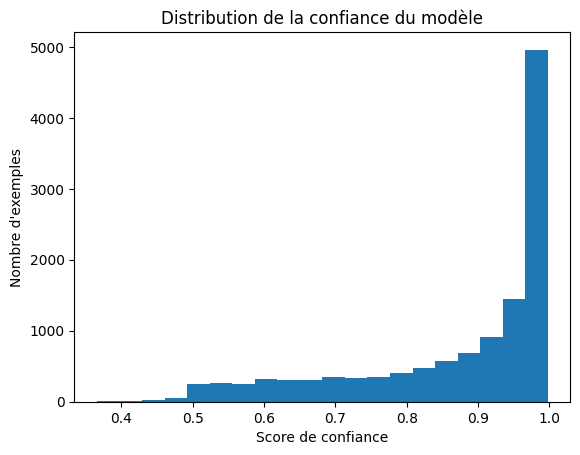

In [13]:
# Task 4: Evaluation
metrics = trainer.evaluate(tokenized_dataset["test"])
print(f"Résultats sur le test set : {metrics}")

# Prédictions pour la calibration
predictions = trainer.predict(tokenized_dataset["test"])
probs = torch.nn.functional.softmax(torch.from_numpy(predictions.predictions), dim=-1)
confidences = probs.max(dim=-1).values.numpy()

import matplotlib.pyplot as plt
plt.hist(confidences, bins=20)
plt.title("Distribution de la confiance du modèle")
plt.xlabel("Score de confiance")
plt.ylabel("Nombre d'exemples")
plt.show()

## 5. Inspection de l'Attention (Explainability)

Pour des insights 'trustworthy', nous visualisons quels mots BERT regarde pour prendre sa décision.

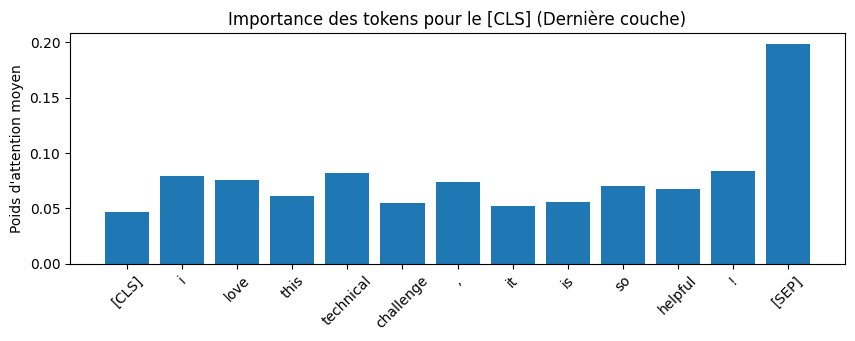

In [14]:
import matplotlib.pyplot as plt
import torch
from transformers import DistilBertForSequenceClassification

model.eval()
text = "I love this technical challenge, it is so helpful!"
inputs = tokenizer(text, return_tensors="pt").to(model.device)

try:
    outputs = model(**inputs, output_attentions=True)
    attention = outputs.attentions[-1]
except (AttributeError, TypeError, IndexError):
    model_eager = DistilBertForSequenceClassification.from_pretrained(model_ckpt, num_labels=3, attn_implementation="eager").to(model.device)
    model_eager.load_state_dict(model.state_dict())
    outputs = model_eager(**inputs, output_attentions=True)
    attention = outputs.attentions[-1]

cls_attention = attention[0, :, 0, :].mean(dim=0).detach().cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(10, 3))
plt.bar(tokens, cls_attention)
plt.title("Importance des tokens pour le [CLS] (Dernière couche)")
plt.xticks(rotation=45)
plt.ylabel("Poids d'attention moyen")
plt.show()

## 6. Production-Ready Inference Helper

Enfin, nous encapsulons la logique dans une fonction `analyze_text()` qui fournit une prédiction fiable accompagnée de ses preuves (tokens les plus influents).

In [17]:
import torch
import json
from transformers import DistilBertForSequenceClassification

# Redéfinition des noms de labels pour le dataset tweet_eval/sentiment
label_names = ['negative', 'neutral', 'positive']

# Optimisation : On initialise le modèle d'explication une seule fois à l'extérieur
print("Initialisation du module d'explicabilité (eager mode)...")
model_explain = DistilBertForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=3,
    attn_implementation="eager"
).to(model.device)
model_explain.load_state_dict(model.state_dict())
model_explain.eval()

def analyze_text(text):
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model_explain(**inputs, output_attentions=True)
        attentions = outputs.attentions

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    conf, pred_idx = torch.max(probs, dim=-1)
    label = label_names[pred_idx.item()]

    evidence = []
    if attentions is not None:
        # Extraction de la dernière couche d'attention
        last_layer = attentions[-1][0].mean(dim=0)
        cls_weights = last_layer[0].cpu().numpy()

        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

        token_importance = []
        for i, (token, weight) in enumerate(zip(tokens, cls_weights)):
            # Filtrage des tokens techniques
            if token not in ['[CLS]', '[SEP]', '[PAD]'] and not token.startswith('##') and len(token) > 1:
                token_importance.append((token, float(weight)))

        token_importance.sort(key=lambda x: x[1], reverse=True)
        evidence = [t for t, a in token_importance[:3]]

    return {
        "sentiment": label,
        "confidence": f"{conf.item():.2%}",
        "top_evidence": evidence if evidence else "Non disponible"
    }

# Batterie de tests
tests = [
    "I absolutely love how this model works, it is amazing!",
    "This is a total disaster, I am very disappointed.",
    "The weather today is just average, nothing special."
]

for t in tests:
    print(f"\nTexte: {t}")
    print(json.dumps(analyze_text(t), indent=2))

Initialisation du module d'explicabilité (eager mode)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Texte: I absolutely love how this model works, it is amazing!
{
  "sentiment": "positive",
  "confidence": "99.25%",
  "top_evidence": [
    "works",
    "it",
    "model"
  ]
}

Texte: This is a total disaster, I am very disappointed.
{
  "sentiment": "negative",
  "confidence": "99.30%",
  "top_evidence": [
    "am",
    "is",
    "this"
  ]
}

Texte: The weather today is just average, nothing special.
{
  "sentiment": "negative",
  "confidence": "69.58%",
  "top_evidence": [
    "nothing",
    "average",
    "is"
  ]
}


## 6. Production-Ready Inference Helper

Enfin, nous encapsulons la logique dans une fonction `analyze_text()` qui fournit une prédiction fiable accompagnée de ses preuves (tokens les plus influents).

In [18]:
# Cellule supprimée car redondante et erronée (NameError: model_eval)
# La fonction finale est définie et testée dans la cellule 072dddff